In [ ]:
!pip install langchain langchain-core langchain-community \
pypdf pymupdf sentence-transformers faiss-cpu chromadb



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.3/331.3 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 

In [ ]:
import langchain
import pypdf
import pymupdf
import sentence_transformers
import faiss
import chromadb
import os

print("All libraries imported successfully!")


All libraries imported successfully!


In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer #embedding model will be inside this
from chromadb.config import Settings
import uuid #it will create the id for every record that we insert in db
from typing import List,Dict,Any,Tuple
from sklearn.metrics.pairwise import cosine_similarity
!pip install langchain langchain-community


## **DOCUMENT STRUCTURE**

In [ ]:
from langchain_core.documents import Document

In [ ]:
doc=Document(
    page_content="This is my document. It is the second document",
      #inorder to improve search query retrieval we use metadata
    metadata={
        "source":"example.txt",
        "page":"1",
        "author":"ahmed"

     }
)
doc

Document(metadata={'source': 'example.txt', 'page': '1', 'author': 'ahmed'}, page_content='This is my document. It is the second document')

we are providing extra information in the document because when we store the embedding of the document in the vector database we can filter the result through this information that is present inside the meta data

In [ ]:
#create a simple txt file
import os
os.makedirs("../data/text_file",exist_ok=True)

In [ ]:
content = {"../data/text_file/pythonintro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive libraries
- Cross-platform compatibility
- Strong community support
"""
}

for file_path, content in content.items():
    with open(file_path, 'w',encoding="utf-8") as file:
        file.write(content)
print("sample file has been created")

sample file has been created


## **TEXT LOADER**

In [ ]:
#TextLoader is used to read the text
from langchain_community.document_loaders import TextLoader


In [ ]:
#importing the text from the single file
loader=TextLoader("../data/text_file/pythonintro.txt",encoding="utf-8")
data=loader.load()
data
#

[Document(metadata={'source': '../data/text_file/pythonintro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive libraries\n- Cross-platform compatibility\n- Strong community support\n')]

In [ ]:
#importing all the files from directory loader
from langchain_community.document_loaders import DirectoryLoader
dir_loader=DirectoryLoader("../data/text_file/",
                           glob="*.txt", #pattern to match
                           loader_cls=TextLoader ,#for each file there is a diff loader so basically loader_cls help which loader to use for different files
                           loader_kwargs={"encoding":"utf-8"})
docs=dir_loader.load()
docs

[Document(metadata={'source': '../data/text_file/pythonintro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive libraries\n- Cross-platform compatibility\n- Strong community support\n')]

In [ ]:
#in order to import only pdf file from directory
from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader

dir_loader=DirectoryLoader("../data/text_file/",
                           glob="*.pdf", #pattern to match
                           loader_cls=PyMuPDFLoader ,#for each file there is a diff loader so basically loader_cls help which loader to use for different files
                           )
docs=dir_loader.load()
docs




[Document(metadata={'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2023-11-13T15:58:35+05:00', 'source': '../data/text_file/Introduction to Artificial Intelligence CT-262 (1).pdf', 'file_path': '../data/text_file/Introduction to Artificial Intelligence CT-262 (1).pdf', 'total_pages': 42, 'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2023-11-13T15:58:35+05:00', 'trapped': '', 'modDate': "D:20231113155835+05'00'", 'creationDate': "D:20231113155835+05'00'", 'page': 0}, page_content='Practical Workbook \n \nCT-262 \n \nINTRODUCTION TO \nARTIFICIAL INTELLIGENCE  \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \n \nName: \n \n \n \nRoll No: \n \n \n \nBatch: \n \n \n \nDepartment:'),
 Document(metadata={'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2023-11-13T15:58:35+05:00', 'source': '../data

## **CHUNKING**

In [ ]:
!pip install langchain-text-splitters


In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [ ]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""
    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n", "\n", " ", ""]
    )
    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")

    return split_docs

In [ ]:
chunks=split_documents(docs)
chunks

Split 1 documents into 1 chunks

Example chunk:
Content: Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has b...
Metadata: {'source': '../data/text_file/pythonintro.txt'}


[Document(metadata={'source': '../data/text_file/pythonintro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive libraries\n- Cross-platform compatibility\n- Strong community support')]

## **EMBEDDINGS**

In [ ]:
#Creating the embedding part
class EmbeddingManager:
  """Handles document embedding generation using sentenceTransformer"""

  def __init__(self,model_name: str="all-MiniLM-L6-v2"): #this model is responsible for converting text into embedding
    """
    Initializes the EmbeddingManager

    Args:
      model_name : HuggingFace model name for sentence embeddings.
    """
    self.model_name = model_name
    self.model=None
    self._load_model()

  def _load_model(self):
    """Loads the sentence transformer model"""
    try:
      print(f"Loading embedding model: {self.model_name}")
      self.model=SentenceTransformer(self.model_name)
      print(f"Model loaded successfully.Embedding dimension:{self.model.get_sentence_embedding_dimension()}")
    except Exception as e:
      print(f"Error loading model{self.model_name}:{e}")
      raise

  def generat_embeddings(self,texts:list[str])->np.ndarray: #returns numpy array
    """
    Generate embeddings for a list of texts

    Args:
        texts:List of text strings to embed

    Returns:
        numpy array of embeddings with shape (len(texts),embedding_dim)

    """
    if not self.model:
      raise ValueError("Model not loaded")
    print(f"Generating embeddings for {len(texts)} texts...")
    embeddings=self.model.encode(texts,show_progress_bar=True)
    print(f"Generated embeddings with shape:{embeddings.shape}")
    return embeddings

#initialize the embedding manager
embedding_manager=EmbeddingManager()
embedding_manager



Loading embedding model: all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.Embedding dimension:384


## **VECTOR STORE**

In [ ]:
from chromadb.api.models.CollectionCommon import Embeddings
class VectorStore:
  """Manages document embeddings in a ChromaDB vector store"""
  def __init__(self,collection_name:str="pdf_document",persist_directory="../data/vector_store"):
    """
    Initializes the VectorStore

    Args:
      collection_name:Name of the ChromaDB collection to store documents
      persist_directory:Directory to persist the vectore store
    """
    self.collection_name=collection_name
    self.persist_directory=persist_directory
    self.client=None
    self.collection=None
    self._initialize_store()

  def _initialize_store(self):
    """initialize the chromaDB client and collection """
    try:
      #create persistent chromaDB client
      os.makedirs(self.persist_directory,exist_ok=True) #ChromaDB needs a directory to save the vector database.
      self.client=chromadb.PersistentClient(path=self.persist_directory)#store embedding on the disk so that it cannot dissapear
      #get or create collection
      self.collection=self.client.get_or_create_collection(name=self.collection_name,
              metadata={"discription":"PDF document embedding for Rag"})
      print(f"Vector store initialized. Collection:{self.collection_name}")
      print(f"exsisting document in collection:{self.collection.count()}") #this show how many docs are already stored

    except Exception as e:
      print(f"Error initializing vector store:{e}")
      raise

  def add_documents(self,documents:List[Any],embeddings:np.ndarray):
    """
    Add documents and their embeddings to the vector store

    Args:
        documents:List of Langchain documents
        embeddings:Crossponding embeddings for the documents
    """
    if len(documents)!=len(embeddings):
      raise ValueError("Number of documents and embeddings must be equal")

    print(f"Adding {len(documents)} documents to vector store...")

    #Prepare data for ChromaDB
    ids=[]
    metadatas=[]
    document_text=[]
    embedding_list=[]

    for i,(doc,embedding) in enumerate(zip(documents,embeddings)):
      #Generate unique ids
      doc_id=f"doc_{uuid.uuid4().hex[:8]}_{i}"
      ids.append(doc_id)

      #prepare the metadata
      metadata=dict(doc.metadata)
      metadata['doc_index']=i
      metadata['content_length']=len(doc.page_content)
      metadatas.append(metadata)

      document_text.append(doc.page_content)
      embedding_list.append(embedding.tolist())
      self.collection.add(
        ids=ids,
        documents=document_text,
        metadatas=metadatas,
        embeddings=embedding_list
    )
      print(f"Added {len(documents)} documents to the vector store.")


vectorstore=VectorStore()
vectorstore



Vector store initialized. Collection:pdf_document
exsisting document in collection:0


In [ ]:
#Extracting the chunks to generate the embeddings
text=[doc.page_content for doc in chunks]

#Generate the embeddings
embeddings=embedding_manager.generat_embeddings(text)
embeddings

#store embeddings into the database
vectorstore.add_documents(chunks,embeddings)


Generating embeddings for 1 texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generated embeddings with shape:(1, 384)
Adding 1 documents to vector store...
Added 1 documents to the vector store.


## **RETRIEVER PIPELINE FOR VECTOR STORE**

In [ ]:
class RAGRetriever:
    """Handles query-based retrieval from the vector store"""

    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever

        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager

    def retrieve(self, query: str, top_k: int = 5, score_threshold: float = 0.0) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query

        Args:
            query: The search query
            top_k: Number of top results to return
            score_threshold: Minimum similarity score threshold

        Returns:
            List of dictionaries containing retrieved documents and metadata
        """
        print(f"Retrieving documents for query: '{query}'")
        print(f"Top K: {top_k}, Score threshold: {score_threshold}")

        # Generate query embedding
        query_embedding = self.embedding_manager.generat_embeddings([query])[0]

        # Search in vector store
        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k
            )

            # Process results
            retrieved_docs = []

            if results['documents'] and results['documents'][0]:
                documents = results['documents'][0]
                metadatas = results['metadatas'][0]
                distances = results['distances'][0]
                ids = results['ids'][0]

                for i, (doc_id, document, metadata, distance) in enumerate(zip(ids, documents, metadatas, distances)):
                    # Convert distance to similarity score (ChromaDB uses cosine distance)
                    similarity_score = 1 - distance

                    if similarity_score >= score_threshold:
                        retrieved_docs.append({
                            'id': doc_id,
                            'content': document,
                            'metadata': metadata,
                            'similarity_score': similarity_score,
                            'distance': distance,
                            'rank': i + 1
                        })

                print(f"Retrieved {len(retrieved_docs)} documents (after filtering)")
            else:
                print("No documents found")

            return retrieved_docs

        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

rag_retriever = RAGRetriever(vectorstore, embedding_manager)
results = rag_retriever.retrieve("what is Python")
print(results)


Retrieving documents for query: 'what is Python'
Top K: 5, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generated embeddings with shape:(1, 384)
Retrieved 1 documents (after filtering)
[{'id': 'doc_d695f772_0', 'content': 'Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive libraries\n- Cross-platform compatibility\n- Strong community support', 'metadata': {'doc_index': 0, 'source': '../data/text_file/pythonintro.txt', 'content_length': 384}, 'similarity_score': 0.6963342726230621, 'distance': 0.30366572737693787, 'rank': 1}]


## **RAG QUERY RETRIEVAL**

In [ ]:
import os
from google.colab import userdata

api_key = userdata.get("groq_key")
os.environ["groq_key"] = api_key
print("Key loaded successfully!" if api_key else "Key not found")

Key loaded successfully!


In [ ]:
!pip install -U langchain-groq

In [ ]:
from langchain_groq import ChatGroq

In [ ]:
#simple RAG function to retrive the context + generate response

def rag_simple(query,llm,retriever,top_k=3):
  #retrieve the context
  result=retriever.retrieve(query,top_k=top_k)
  context="\n\n".join([docs['content'] for docs in result]) if result else ""
  if not context:
    return "No relevant documents found"

  #generate answer using the grok llm
  prompt=f"""use the following context to answer the question concisely.
  Context:{context}
  Question:{query}
  Answer:"""
  response=llm.invoke([prompt.format(context=context,query=query)])
  return response.content


In [ ]:
answer=rag_simple("what is python",llm,rag_retriever)
print(answer)

Retrieving documents for query: 'what is python'
Top K: 3, Score threshold: 0.0
Generating embeddings for 1 texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generated embeddings with shape:(1, 384)
Retrieved 1 documents (after filtering)
Python is a high-level, interpreted programming language known for its simplicity and readability.


## **ENHANCED RAG PIPELINE FEATURES**

HERE WE HAVE DETAILED INFO ABOUT THE SOURCE,CONTEXT,CONFIDENCE

In [ ]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, min_score=0.2, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k, score_threshold=min_score)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}

    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': doc['similarity_score'],
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = max([doc['similarity_score'] for doc in results])

    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])

    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("who created python", rag_retriever, llm, top_k=3, min_score=0.1, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])

Retrieving documents for query: 'who created python'
Top K: 3, Score threshold: 0.1
Generating embeddings for 1 texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Generated embeddings with shape:(1, 384)
Retrieved 1 documents (after filtering)
Answer: Guido van Rossum.
Sources: [{'source': '../data/text_file/pythonintro.txt', 'page': 'unknown', 'score': 0.41730058193206787, 'preview': 'Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.\n\nKey Features:\n- Easy to learn and...'}]
Confidence: 0.41730058193206787
Context Preview: Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular programming languages in the world.

Key Features:
- Easy to learn and


# **BUILDING RAG WITH TYPESENSE**

In [ ]:
!pip install typesense

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.7/140.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
import typesense

In [ ]:
#we will create client so that we can communicate with the cloud

import typesense

client = typesense.Client({
    'nodes': [{
        'host': userdata.get('TYPESENSE_HOST'),
        'port': '443',
        'protocol': 'https'
    }],
    'api_key': 'userdata.get('TYPESENSE_API_KEY'),
    'connection_timeout_seconds': 2
})

In [ ]:
#The reason for creating the particular schema is that we will create our own collection and we will add that schema inside it
books_schema = {
  'name': 'books',
  'fields': [
    {'name': 'title', 'type': 'string'},
    {'name': 'authors', 'type': 'string[]', 'facet': True},
    {'name': 'publication_year', 'type': 'int32', 'facet': True},
    {'name': 'ratings_count', 'type': 'int32'},
    {'name': 'average_rating', 'type': 'float'}
  ],
  'default_sorting_field': 'ratings_count'
}
print(client.collections.create(books_schema))

{'created_at': 1772097329, 'curation_sets': [], 'default_sorting_field': 'ratings_count', 'enable_nested_fields': False, 'fields': [{'facet': False, 'index': True, 'infix': False, 'locale': '', 'name': 'title', 'optional': False, 'sort': False, 'stem': False, 'stem_dictionary': '', 'store': True, 'truncate_len': 100, 'type': 'string'}, {'facet': True, 'index': True, 'infix': False, 'locale': '', 'name': 'authors', 'optional': False, 'sort': False, 'stem': False, 'stem_dictionary': '', 'store': True, 'truncate_len': 100, 'type': 'string[]'}, {'facet': True, 'index': True, 'infix': False, 'locale': '', 'name': 'publication_year', 'optional': False, 'sort': True, 'stem': False, 'stem_dictionary': '', 'store': True, 'truncate_len': 100, 'type': 'int32'}, {'facet': False, 'index': True, 'infix': False, 'locale': '', 'name': 'ratings_count', 'optional': False, 'sort': True, 'stem': False, 'stem_dictionary': '', 'store': True, 'truncate_len': 100, 'type': 'int32'}, {'facet': False, 'index': T

In [ ]:
with open("/books.jsonl","r",encoding="utf-8") as books_json:
  data=books_json.read()
  client.collections["books"].documents.import_(data)


In [ ]:
search_parameters={
    'q':'Harry Porter',
    'query_by':'title,authors',
    'sort_by':'ratings_count:desc'

}
client.collections['books'].documents.search(search_parameters)

{'facet_counts': [],
 'found': 17,
 'hits': [{'document': {'authors': ['J.K. Rowling', ' Mary GrandPré'],
    'average_rating': 4.44,
    'id': '2',
    'image_url': 'https://images.gr-assets.com/books/1474154022m/3.jpg',
    'publication_year': 1997,
    'ratings_count': 4602479,
    'title': "Harry Potter and the Philosopher's Stone"},
   'highlight': {'title': {'matched_tokens': ['Harry', 'Potter'],
     'snippet': "<mark>Harry</mark> <mark>Potter</mark> and the Philosopher's Stone"}},
   'highlights': [{'field': 'title',
     'matched_tokens': ['Harry', 'Potter'],
     'snippet': "<mark>Harry</mark> <mark>Potter</mark> and the Philosopher's Stone"}],
   'text_match': 1157451402721626233,
   'text_match_info': {'best_field_score': '2211864313857',
    'best_field_weight': 15,
    'fields_matched': 1,
    'num_tokens_dropped': 0,
    'score': '1157451402721626233',
    'tokens_matched': 2,
    'typo_prefix_score': 2}},
  {'document': {'authors': ['J.K. Rowling', ' Mary GrandPré', ' R

# **AGENTIC RAG**

In [ ]:
!pip install langchain

In [ ]:
!pip install openai
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 1.8 MB/s eta 0:00:00


In [ ]:
!pip install -U langchain langchain-community faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
!pip install -U langchain-text-splitters

In [ ]:
import os
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

In [ ]:
#initialize the model
llm=ChatOpenAI(model="gpt-4.1",temperature=0)
from langchain_community.embeddings import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

/tmp/ipykernel_10550/1599700349.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
llm

ChatOpenAI(profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x7f4b79e3c230>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x7f4b7a0dc740>, root_client=<openai.OpenAI object at 0x7f4b7b198cb0>, root_async_client=<openai.AsyncOpenAI object at 0x7f4b79f9d880>, model_name='gpt-4.1', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

## **STATE DEFINITION**

In [ ]:
class AgentState(TypedDict):
    question: str
    documents: List[Document]
    answer: str
    needs_retrieval: bool

In [ ]:
### Sample Docuemnt And VectorStore
# Sample documents for demonstration
sample_texts = [
    "LangGraph is a library for building stateful, multi-actor applications with LLMs. It extends LangChain with the ability to coordinate multiple chains across multiple steps of computation in a cyclic manner.",
    "RAG (Retrieval-Augmented Generation) is a technique that combines information retrieval with text generation. It retrieves relevant documents and uses them to provide context for generating more accurate responses.",
    "Vector databases store high-dimensional vectors and enable efficient similarity search. They are commonly used in RAG systems to find relevant documents based on semantic similarity.",
    "Agentic systems are AI systems that can take actions, make decisions, and interact with their environment autonomously. They often use planning and reasoning capabilities."
]
document=[Document(page_content=text) for text in sample_texts]
vectorestore=FAISS.from_documents(document,embeddings)
retriever=vectorestore.as_retriever(k=3)

## **AGENT FUNCTION**

In [ ]:
def decide_retrieval(state: AgentState) -> AgentState:
    """
    Decide if we need to retrieve documents based on the question
    """
    question = state["question"]

    # Simple heuristic: if question contains certain keywords, retrieve
    retrieval_keywords = ["what", "how", "explain", "describe", "tell me"]
    needs_retrieval = any(keyword in question.lower() for keyword in retrieval_keywords)

    return {**state, "needs_retrieval": needs_retrieval}

In [ ]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    Retrieve relevant documents based on the question
    """
    question = state["question"]
    documents = retriever.invoke(question)

    return {**state, "documents": documents}

In [ ]:
def generate_answer(state: AgentState) -> AgentState:
    """
    Generate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents", [])

    if documents:
        # RAG approach: use documents as context
        context = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:

Context:
{context}

Question: {question}

Answer:"""
    else:
        # Direct response without retrieval
        prompt = f"Answer the following question: {question}"

    response = llm.invoke(prompt)
    answer = response.content

    return {**state, "answer": answer}

## **CONDITIONAL LOGIC**

In [ ]:
def should_retrieval(state:AgentState) -> str:
    """
    Determine the next step based on the retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

## **BUILD THE GRAPH**

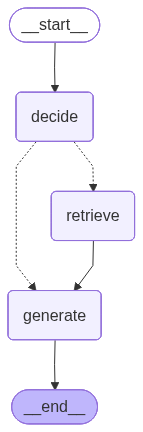

In [ ]:
workflow=StateGraph(AgentState)
workflow.add_node("decide",decide_retrieval)
workflow.add_node("retrieve",retrieve_documents)
workflow.add_node("generate",generate_answer)

# Set entry point
workflow.set_entry_point("decide")

# Add conditional edges
workflow.add_conditional_edges(
    "decide",
    should_retrieval,
    {
        "retrieve": "retrieve",
        "generate": "generate"
    }
)
# Add edges
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
app = workflow.compile()
app

# **TESTING PHASE**

In [ ]:
def ask_question(question: str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state = {
        "question": question,
        "documents": [],
        "answer": "",
        "needs_retrieval": False
    }

    result = app.invoke(initial_state)
    return result